# 04 — Evaluation & comparison

Loads the best checkpoint per model and evaluates both on the **test** split.

Covers assignment **steps 8 and 9**.

> **This is the first and only use of the test split.** Notebooks 01–03 use
> train and dev exclusively; every modelling decision (max_length, class
> weights, learning rate, batch size, epoch count) was made on dev. Test is
> read once, here, to report final numbers.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from transformers import AutoModelForSequenceClassification, AutoTokenizer

sys.path.insert(0, str(Path.cwd().parent / "src"))
import utils  # noqa: E402

utils.ensure_dirs()
utils.set_seed()
sns.set_theme(style="whitegrid", context="notebook")

test = pd.read_csv(utils.DATA_PROCESSED / "test.csv")
search = pd.read_csv(utils.RESULTS / "hparam_search.csv")
with open(utils.RESULTS / "best_configs.json", encoding="utf-8") as fh:
    best_configs = json.load(fh)

print(f"test utterances: {len(test)}")
best_configs

test utterances: 2610


{'bert': {'learning_rate': 2e-05,
  'batch_size': 16,
  'best_epoch': 3,
  'dev_weighted_f1': 0.603,
  'dev_macro_f1': 0.5009,
  'checkpoint': 'checkpoints\\bert\\best'},
 'roberta': {'learning_rate': 5e-05,
  'batch_size': 16,
  'best_epoch': 4,
  'dev_weighted_f1': 0.5843,
  'dev_macro_f1': 0.4468,
  'checkpoint': 'checkpoints\\roberta\\best'}}

## 1. Predict on test

In [2]:
@torch.no_grad()
def predict(model_key: str, texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Return logits for `texts` from the promoted best checkpoint of `model_key`."""
    ckpt = utils.CHECKPOINTS / model_key / "best"
    tok = AutoTokenizer.from_pretrained(ckpt)
    model = AutoModelForSequenceClassification.from_pretrained(ckpt).cuda().eval()

    out = []
    for i in range(0, len(texts), batch_size):
        batch = tok(
            texts[i : i + batch_size],
            padding=True,
            truncation=True,
            max_length=utils.MAX_LENGTH,
            return_tensors="pt",
        ).to("cuda")
        out.append(model(**batch).logits.float().cpu().numpy())

    del model
    torch.cuda.empty_cache()
    return np.concatenate(out)


y_true = test["label"].to_numpy()
texts = test["text"].tolist()

logits, preds = {}, {}
for model_key in utils.MODELS:
    logits[model_key] = predict(model_key, texts)
    preds[model_key] = logits[model_key].argmax(-1)
    print(f"{model_key}: predicted {len(preds[model_key])} utterances")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

bert: predicted 2610 utterances


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

roberta: predicted 2610 utterances


## 2. Headline metrics (step 8)

A **majority-class baseline** (always predict neutral) is included as the
reference point — on a 48%-neutral test split, accuracy alone is easy to
mistake for competence.

In [3]:
rows = []

majority = np.zeros_like(y_true)  # neutral == label id 0
rows.append({
    "model": "majority baseline (always neutral)",
    "weighted_f1": f1_score(y_true, majority, average="weighted", zero_division=0),
    "macro_f1": f1_score(y_true, majority, average="macro", zero_division=0),
    "accuracy": accuracy_score(y_true, majority),
})

for model_key, p in preds.items():
    cfg = best_configs[model_key]
    rows.append({
        "model": utils.MODELS[model_key],
        "weighted_f1": f1_score(y_true, p, average="weighted", zero_division=0),
        "macro_f1": f1_score(y_true, p, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_true, p),
        "lr": cfg["learning_rate"],
        "batch_size": cfg["batch_size"],
        "best_epoch": cfg["best_epoch"],
        "dev_weighted_f1": cfg["dev_weighted_f1"],
    })

test_metrics = pd.DataFrame(rows)
# Round only the metric columns — rounding `lr` would flatten 2e-5 to 0.0.
metric_cols = ["weighted_f1", "macro_f1", "accuracy", "dev_weighted_f1"]
test_metrics[metric_cols] = test_metrics[metric_cols].round(4)
test_metrics.to_csv(utils.RESULTS / "test_metrics.csv", index=False)
test_metrics

,model,weighted_f1,macro_f1,accuracy,lr,batch_size,best_epoch,dev_weighted_f1
0,majority baseline (always neutral),0.3127,0.0928,0.4812,NaN,NaN,NaN,NaN
1,bert-base-uncased,0.5928,0.4343,0.5759,0.00002,16.0,3.0,0.6030
2,roberta-base,0.6050,0.4599,0.5908,0.00005,16.0,4.0,0.5843


## 3. Per-class breakdown

In [4]:
per_class = []
for model_key, p in preds.items():
    rep = classification_report(
        y_true, p, target_names=utils.LABEL_NAMES, output_dict=True, zero_division=0
    )
    for name in utils.LABEL_NAMES:
        per_class.append({
            "model": model_key,
            "emotion": name,
            "precision": round(rep[name]["precision"], 4),
            "recall": round(rep[name]["recall"], 4),
            "f1": round(rep[name]["f1-score"], 4),
            "support": int(rep[name]["support"]),
        })

per_class_df = pd.DataFrame(per_class)
per_class_df.to_csv(utils.RESULTS / "test_per_class.csv", index=False)
per_class_df.pivot(index="emotion", columns="model", values="f1").loc[utils.LABEL_NAMES]

model,bert,roberta
emotion,,
neutral,0.7250,0.7358
joy,0.6023,0.5852
surprise,0.5794,0.5494
anger,0.4111,0.4620
sadness,0.3100,0.3537
disgust,0.2754,0.3111
fear,0.1368,0.2222


In [5]:
for model_key, p in preds.items():
    print(f"\n===== {utils.MODELS[model_key]} =====")
    print(classification_report(y_true, p, target_names=utils.LABEL_NAMES, zero_division=0, digits=3))


===== bert-base-uncased =====
              precision    recall  f1-score   support

     neutral      0.809     0.657     0.725      1256
         joy      0.554     0.659     0.602       402
    surprise      0.515     0.662     0.579       281
       anger      0.509     0.345     0.411       345
     sadness      0.278     0.351     0.310       208
     disgust      0.271     0.279     0.275        68
        fear      0.087     0.320     0.137        50

    accuracy                          0.576      2610
   macro avg      0.432     0.468     0.434      2610
weighted avg      0.628     0.576     0.593      2610


===== roberta-base =====
              precision    recall  f1-score   support

     neutral      0.804     0.678     0.736      1256
         joy      0.581     0.590     0.585       402
    surprise      0.485     0.633     0.549       281
       anger      0.497     0.432     0.462       345
     sadness      0.335     0.375     0.354       208
     disgust      0.2

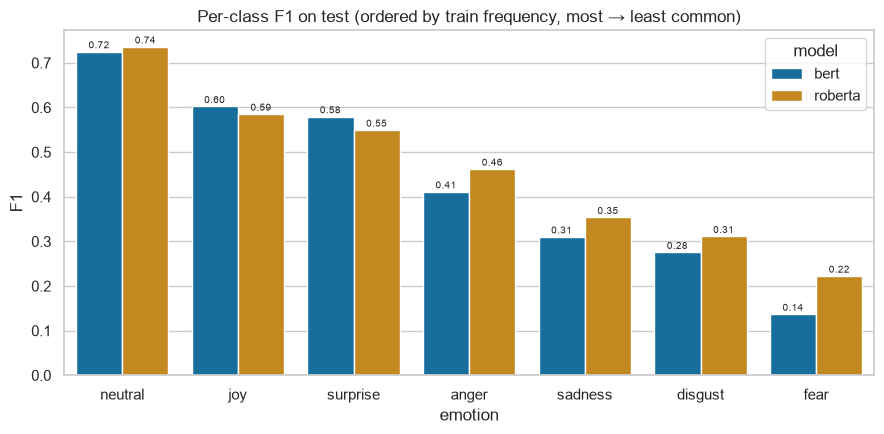

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = per_class_df.copy()
plot_df["emotion"] = pd.Categorical(plot_df["emotion"], categories=utils.LABEL_NAMES, ordered=True)
sns.barplot(data=plot_df, x="emotion", y="f1", hue="model", ax=ax, palette="colorblind")
ax.set_title("Per-class F1 on test (ordered by train frequency, most → least common)")
ax.set_ylabel("F1")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=1)
fig.tight_layout()
fig.savefig(utils.FIGURES / "per_class_f1.png", dpi=150)
plt.show()

## 4. Confusion matrices (step 8)

Row-normalized: each row sums to 1, so cell (i, j) reads "of all true class
i utterances, what fraction were predicted j". Normalizing by row is what
makes rare classes legible — in raw counts, fear (50 test utterances) is
invisible next to neutral (1,256).

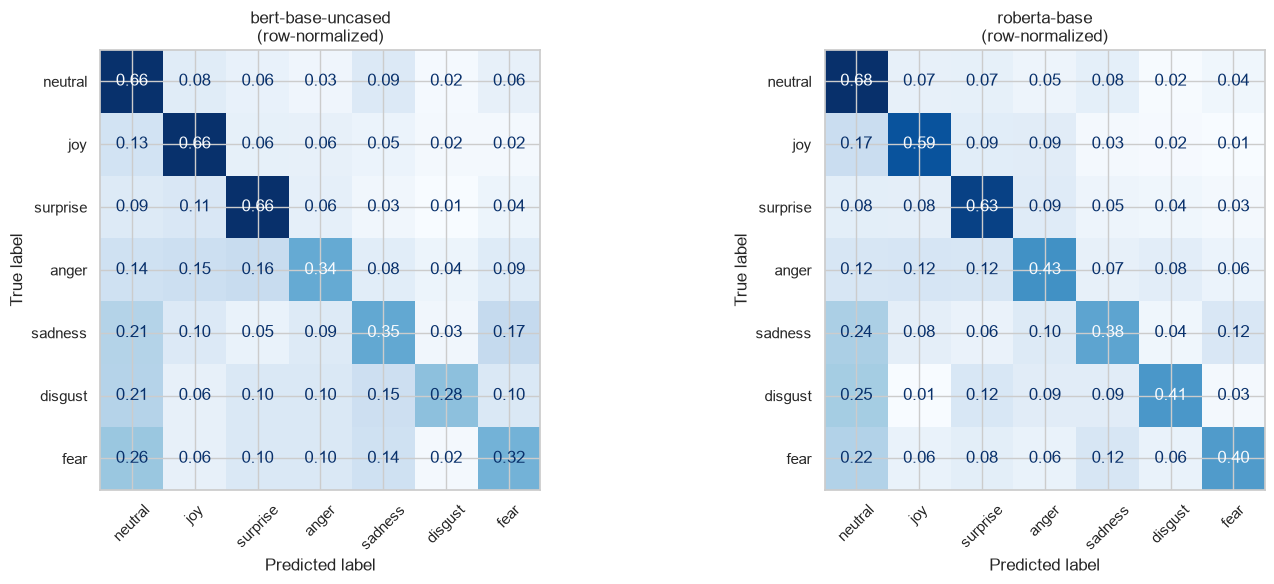

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (model_key, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_true, p, normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=utils.LABEL_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False, xticks_rotation=45)
    ax.set_title(f"{utils.MODELS[model_key]}\n(row-normalized)")
fig.tight_layout()
fig.savefig(utils.FIGURES / "confusion_matrices.png", dpi=150)
plt.show()

In [8]:
# Top confusion pairs (off-diagonal), by rate and by raw count.
conf_rows = []
for model_key, p in preds.items():
    cm_rate = confusion_matrix(y_true, p, normalize="true")
    cm_count = confusion_matrix(y_true, p)
    for i, true_name in enumerate(utils.LABEL_NAMES):
        for j, pred_name in enumerate(utils.LABEL_NAMES):
            if i != j:
                conf_rows.append({
                    "model": model_key,
                    "true": true_name,
                    "predicted": pred_name,
                    "rate": round(cm_rate[i, j], 4),
                    "count": int(cm_count[i, j]),
                })

confusions = pd.DataFrame(conf_rows)
confusions.to_csv(utils.RESULTS / "confusion_pairs.csv", index=False)

for model_key in preds:
    top = confusions[confusions.model == model_key].nlargest(3, "rate")
    print(f"\n{utils.MODELS[model_key]} — top 3 confusion pairs by rate:")
    for _, r in top.iterrows():
        print(f"  {r['true']:9s} -> {r['predicted']:9s}  {100 * r['rate']:5.1f}% ({r['count']} utterances)")


bert-base-uncased — top 3 confusion pairs by rate:
  fear      -> neutral     26.0% (13 utterances)
  sadness   -> neutral     20.7% (43 utterances)
  disgust   -> neutral     20.6% (14 utterances)

roberta-base — top 3 confusion pairs by rate:
  disgust   -> neutral     25.0% (17 utterances)
  sadness   -> neutral     23.6% (49 utterances)
  fear      -> neutral     22.0% (11 utterances)


In [9]:
# How much of the total error is "collapsed into neutral"?
for model_key, p in preds.items():
    wrong = y_true != p
    into_neutral = wrong & (p == utils.LABEL2ID["neutral"])
    from_neutral = wrong & (y_true == utils.LABEL2ID["neutral"])
    print(f"{model_key:8s} errors={wrong.sum():4d} | "
          f"predicted neutral when it wasn't: {into_neutral.sum():4d} ({100*into_neutral.sum()/wrong.sum():.1f}% of errors) | "
          f"true neutral misread as emotion: {from_neutral.sum():4d} ({100*from_neutral.sum()/wrong.sum():.1f}%)")

bert     errors=1107 | predicted neutral when it wasn't:  195 (17.6% of errors) | true neutral misread as emotion:  431 (38.9%)
roberta  errors=1068 | predicted neutral when it wasn't:  208 (19.5% of errors) | true neutral misread as emotion:  404 (37.8%)


## 5. Did class weighting do what we hoped? (step 4c revisited)

The weighted loss should trade precision for recall on rare classes. If it
worked, rare classes should show recall clearly above what their frequency
would predict, with precision below their recall.

In [10]:
weighting_check = per_class_df.merge(
    pd.DataFrame({
        "emotion": utils.LABEL_NAMES,
        "train_pct": [100 * c / 9989 for c in [4710, 1743, 1205, 1109, 683, 271, 268]],
    }),
    on="emotion",
)
weighting_check["recall_minus_precision"] = (
    weighting_check["recall"] - weighting_check["precision"]
).round(4)
weighting_check.sort_values(["model", "train_pct"], ascending=[True, False])[
    ["model", "emotion", "train_pct", "precision", "recall", "recall_minus_precision"]
]

,model,emotion,train_pct,precision,recall,recall_minus_precision
0,bert,neutral,47.151867,0.8088,0.6568,-0.1520
1,bert,joy,17.449194,0.5544,0.6592,0.1048
2,bert,surprise,12.063270,0.5152,0.6619,0.1467
3,bert,anger,11.102212,0.5085,0.3449,-0.1636
4,bert,sadness,6.837521,0.2776,0.3510,0.0734
5,bert,disgust,2.712984,0.2714,0.2794,0.0080
6,bert,fear,2.682951,0.0870,0.3200,0.2330
7,roberta,neutral,47.151867,0.8038,0.6783,-0.1255
8,roberta,joy,17.449194,0.5809,0.5896,0.0087
9,roberta,surprise,12.063270,0.4850,0.6335,0.1485


## 6. Error analysis (step 9)

The sample below is drawn from the errors the better model made with **high
confidence** — cases where it was not merely uncertain but confidently wrong.

In [11]:
best_model = max(best_configs, key=lambda k: best_configs[k]["dev_weighted_f1"])
print(f"error analysis on the better model by dev F1: {utils.MODELS[best_model]}\n")

probs = torch.softmax(torch.tensor(logits[best_model]), dim=-1).numpy()
p = preds[best_model]
err = pd.DataFrame({
    "text": test["text"],
    "gold": [utils.ID2LABEL[i] for i in y_true],
    "pred": [utils.ID2LABEL[i] for i in p],
    "confidence": probs.max(-1).round(3),
    "n_words": test["text"].str.split().str.len(),
})
err = err[err.gold != err.pred]

sample = err.nlargest(10, "confidence")
sample.to_csv(utils.RESULTS / "error_examples.csv", index=False)
sample

error analysis on the better model by dev F1: bert-base-uncased



,text,gold,pred,confidence,n_words
1426,Wow!,joy,surprise,0.956,1
1023,"Whoa-whoa you guys, it's not a cat!",anger,surprise,0.955,7
2061,Sorry.,neutral,sadness,0.950,1
357,"Honey, it isn't good luck.",neutral,sadness,0.944,5
2047,What are we gonna do?,neutral,fear,0.943,5
1433,Okay.,joy,neutral,0.942,1
536,"Whoa, I'm sorry. Excuse me. We had this cart.",anger,surprise,0.941,9
1958,"What. Oh no, you just rolled over the juice box.",sadness,surprise,0.938,10
389,"Please, it's a relief is what it is, is what i...",neutral,sadness,0.934,12
1544,I-I'll go tell her now before Ross finds out a...,neutral,fear,0.933,13


### Are short utterances harder? No — and this refutes the obvious hypothesis

The intuitive story is that short, generic lines ("What?", "Hey.") should be
*hardest*, because their emotion lives in delivery and dialogue context that a
text-only model cannot see. We tested that directly. **It is false**: short
utterances are markedly *easier*.

Two candidate explanations are ruled out below:

1. *"Short utterances are more often neutral, and the model leans neutral."*
   No — the neutral share is nearly identical in both groups (49.0% vs 47.8%).
2. *"It's a class-mix artifact."* No — short utterances score higher on
   **both** neutral recall and non-neutral recall, and on macro F1, which is
   insensitive to class mix.

The likelier explanation is that short emotional lines in this corpus are
**formulaic and lexically explicit** ("Oh my God!", "I'm so sorry") — the
emotion word *is* the utterance. Longer turns carry mixed or hedged content
where the emotional cue is diluted across a sentence.

This does not rescue the context limitation — §5's ambiguity check shows that
is real — but it does relocate it. The problem is not utterance *length*.

In [12]:
correct_len = test.loc[y_true == p, "text"].str.split().str.len()
error_len = test.loc[y_true != p, "text"].str.split().str.len()
print(f"median words — correct: {correct_len.median():.0f} | errors: {error_len.median():.0f}")

short = (test["text"].str.split().str.len() <= 3).to_numpy()
for name, mask in [("<= 3 words", short), ("  > 3 words", ~short)]:
    is_neutral = y_true[mask] == utils.LABEL2ID["neutral"]
    print(
        f"\n{name} (n={mask.sum():4d}): "
        f"acc={accuracy_score(y_true[mask], p[mask]):.3f}  "
        f"weighted_f1={f1_score(y_true[mask], p[mask], average='weighted', zero_division=0):.3f}  "
        f"macro_f1={f1_score(y_true[mask], p[mask], average='macro', zero_division=0):.3f}"
    )
    print(f"    true neutral: {100 * is_neutral.mean():.1f}%  |  "
          f"neutral recall: {(p[mask][is_neutral] == utils.LABEL2ID['neutral']).mean():.3f}  |  "
          f"non-neutral recall: {(p[mask][~is_neutral] == y_true[mask][~is_neutral]).mean():.3f}")

print("\n=> Short utterances are easier on every axis, including macro F1 —"
      "\n   so this is not explained by class mix.")

median words — correct: 6 | errors: 8

<= 3 words (n= 715): acc=0.660  weighted_f1=0.670  macro_f1=0.491
    true neutral: 49.0%  |  neutral recall: 0.691  |  non-neutral recall: 0.630

  > 3 words (n=1895): acc=0.544  weighted_f1=0.564  macro_f1=0.414
    true neutral: 47.8%  |  neutral recall: 0.643  |  non-neutral recall: 0.453

=> Short utterances are easier on every axis, including macro F1 —
   so this is not explained by class mix.


### The real ceiling: identical text, different gold label

This is the honest, quantitative version of the "no dialogue context" claim.
The same string appears in test with **different gold labels** — an
irreducible ceiling for any text-only model, since identical input cannot
produce two different outputs. Whatever distinguishes an angry "Hey!" from a
joyful one is simply not in the text.

In [13]:
dup = test.groupby("text")["label_name"].nunique()
ambiguous = dup[dup > 1]
n_ambig_utts = test["text"].isin(ambiguous.index).sum()
print(f"distinct strings with >1 gold label in test: {len(ambiguous)}")
print(f"test utterances affected: {n_ambig_utts} ({100 * n_ambig_utts / len(test):.1f}%)")
print("\nexamples:")
for text in ambiguous.head(5).index:
    labels = sorted(test.loc[test.text == text, "label_name"].unique())
    print(f"  {text!r:40s} -> {labels}")

distinct strings with >1 gold label in test: 24
test utterances affected: 155 (5.9%)

examples:
  'Are you sure?'                          -> ['neutral', 'surprise']
  'Good.'                                  -> ['joy', 'neutral']
  'Hey!'                                   -> ['anger', 'joy', 'neutral', 'sadness', 'surprise']
  'Hi!'                                    -> ['joy', 'neutral', 'sadness']
  'Huh?'                                   -> ['anger', 'neutral']


## Summary

Written up in full in `report.md` §7–8. Artifacts produced here:

- `results/test_metrics.csv` — headline comparison + majority baseline
- `results/test_per_class.csv` — per-class precision/recall/F1
- `results/confusion_pairs.csv` — every off-diagonal confusion
- `results/error_examples.csv` — high-confidence errors
- `results/figures/confusion_matrices.png`, `per_class_f1.png`